In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pywt
from scipy.ndimage import gaussian_filter, gaussian_filter1d

%load_ext autoreload
%autoreload 2

from deblurring.blurring import blur_and_noise
from deblurring.sparsity import wavelet_l1
from solvers.proximal import ISTASolver

In [2]:
"""Read image and blur with added noise"""

f = plt.imread("../../data/Cameraman256.png")
f = (f - f.min()) / (f.max() - f.min())

theta = 0.02 * np.std(f)  # 2% noise
sigma = 1.0
kernel = partial(gaussian_filter, sigma=sigma)
g = blur_and_noise(f, kernel, theta)

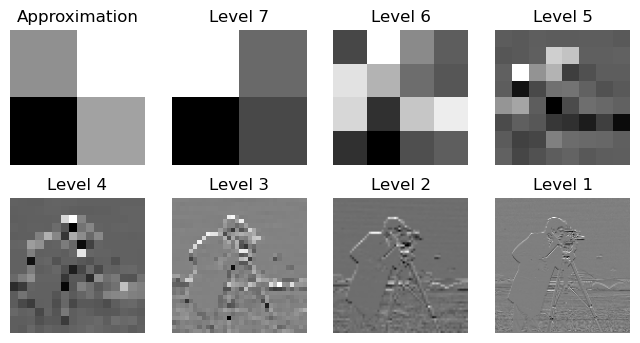

In [3]:
"""Decompose into wavelets"""

wavelets = pywt.wavedec2(f, "haar", level=7)

plt.figure(figsize=(8, 4))
plt.subplot(2, 4, 1)
plt.imshow(wavelets[0], cmap="gray")
plt.axis("off")
plt.title("Approximation")

for idx, (wavelet, _, _) in enumerate(wavelets[1:]):
    plt.subplot(2, 4, idx + 2)
    plt.imshow(wavelet, cmap="gray")
    plt.axis("off")
    plt.title(f"Level {7 - idx}")

plt.show()

[WARNING] 2025-03-25 21:29:37 | Did not converge | solvers.proximal-solve:177
[WARNING] 2025-03-25 21:29:38 | Did not converge | solvers.proximal-solve:177
[WARNING] 2025-03-25 21:29:39 | Did not converge | solvers.proximal-solve:177
[WARNING] 2025-03-25 21:29:40 | Did not converge | solvers.proximal-solve:177


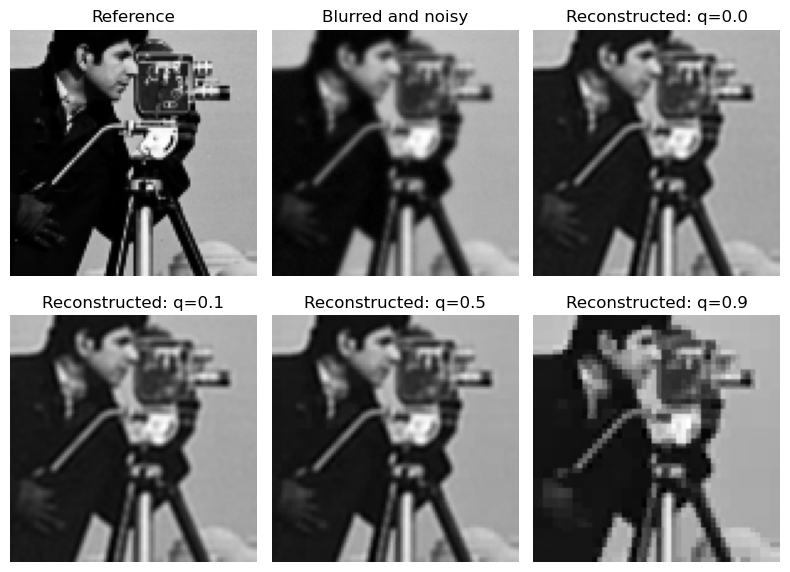

In [5]:
"""Solve using ISTA and L1 regularisation"""

solver = ISTASolver(g, kernel)

plt.figure(figsize=(8, 6))
plt.subplot(2, 3, 1)
plt.imshow(f[50:150, 80:180], cmap="gray")
plt.axis("off")
plt.title("Reference")
plt.subplot(2, 3, 2)
plt.imshow(g[50:150, 80:180], cmap="gray")
plt.axis("off")
plt.title("Blurred and noisy")

for idx, quantile in enumerate([0.0, 0.1, 0.5, 0.9]):
    f_hat = solver.solve(
        lambda_=0.1,
        shrinkage_func=wavelet_l1,
        params={"quantile": quantile, "end_level": 4},
    )
    plt.subplot(2, 3, 3 + idx)
    plt.title(f"Reconstructed: q={quantile}")
    plt.imshow(f_hat[50:150, 80:180], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()